In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

# Download e visão inicial dos dados

In [37]:
symbol = 'MSFT'
start_date = '2024-01-01'
end_date = '2025-10-31'

df = yf.download(symbol, start=start_date, end=end_date)

/var/folders/22/p5w3pds139513tzr6pglg5_00000gn/T/ipykernel_46915/1067247225.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


In [38]:
print('df info:')
print(df.info)

print(f'is there any NaN?: {df.isnull().any().any()}')


df info:
<bound method DataFrame.info of Price            Close        High         Low        Open    Volume
Ticker            MSFT        MSFT        MSFT        MSFT      MSFT
Date                                                                
2024-01-02  365.421570  370.377673  361.381797  368.367634  25258600
2024-01-03  365.155640  367.776566  363.096347  363.589001  23083500
2024-01-04  362.534668  367.618867  361.775991  365.224573  20901500
2024-01-05  362.347504  366.594184  361.115867  363.549582  21004600
2024-01-08  369.185486  369.688003  363.588937  363.874655  23134000
...                ...         ...         ...         ...       ...
2025-10-24  522.631836  524.368576  519.737290  521.813360  15532400
2025-10-27  530.527100  533.581381  528.021779  530.786624  18734700
2025-10-28  541.057373  552.685573  539.759814  548.972552  29986700
2025-10-29  540.538330  545.249544  535.727327  543.922012  36023000
2025-10-30  524.777832  533.970588  521.144617  529.488985  41

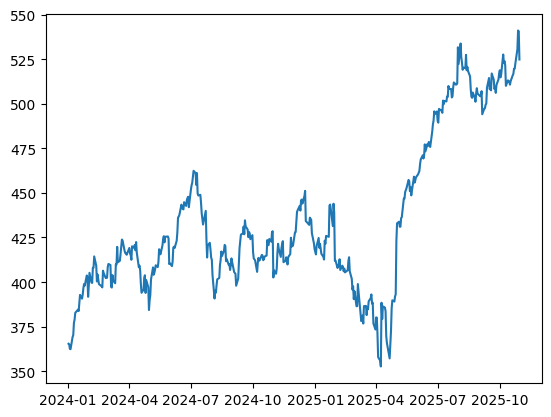

In [39]:
plt.plot(df['Close'])

In [45]:
print('df columns:')
print(df.columns)


df columns:
MultiIndex([( 'Close', 'MSFT'),
            (  'High', 'MSFT'),
            (   'Low', 'MSFT'),
            (  'Open', 'MSFT'),
            ('Volume', 'MSFT')],
           names=['Price', 'Ticker'])


In [49]:
# tirando o segundo nível das colunas
df.columns = df.columns.get_level_values('Price')
df

Price,Close,High,Low,Open,Volume
Date,,,,,
2024-01-02,365.421570,370.377673,361.381797,368.367634,25258600
2024-01-03,365.155640,367.776566,363.096347,363.589001,23083500
2024-01-04,362.534668,367.618867,361.775991,365.224573,20901500
2024-01-05,362.347504,366.594184,361.115867,363.549582,21004600
2024-01-08,369.185486,369.688003,363.588937,363.874655,23134000
...,...,...,...,...,...
2025-10-24,522.631836,524.368576,519.737290,521.813360,15532400
2025-10-27,530.527100,533.581381,528.021779,530.786624,18734700
2025-10-28,541.057373,552.685573,539.759814,548.972552,29986700


# Tratando outliers

In [51]:
# Criando função para tratar outliers

def cap_outliers(df, cols, factor=1.5):
    df = df.copy()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR

        df[col] = df[col].clip(lower, upper) #Valores menores que lower são substituídos por lower. Valores maiores que upper são substituídos por upper. Mantém o tamanho do DataFrame → essencial para LSTM. Evita excluir linhas e quebrar a sequência temporal.
    return df


In [52]:
df_sem_outliers = cap_outliers(df, df.columns)
df_sem_outliers

Price,Close,High,Low,Open,Volume
Date,,,,,
2024-01-02,365.421570,370.377673,361.381797,368.367634,25258600
2024-01-03,365.155640,367.776566,363.096347,363.589001,23083500
2024-01-04,362.534668,367.618867,361.775991,365.224573,20901500
2024-01-05,362.347504,366.594184,361.115867,363.549582,21004600
2024-01-08,369.185486,369.688003,363.588937,363.874655,23134000
...,...,...,...,...,...
2025-10-24,522.631836,524.368576,519.737290,521.813360,15532400
2025-10-27,530.527100,533.581381,528.021779,527.559681,18734700
2025-10-28,530.838505,533.821892,528.809004,527.559681,29986700


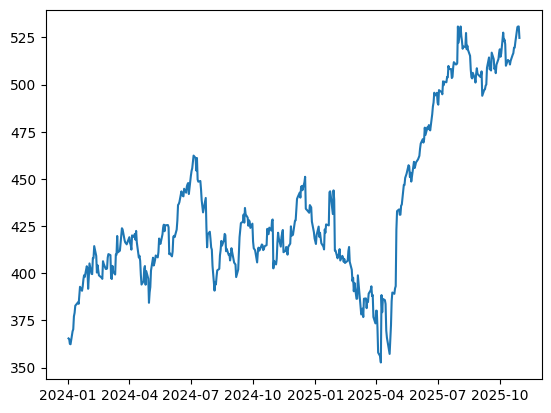

In [55]:
plt.plot(df_sem_outliers['Close'])

In [56]:
# calculando intervalo interquartil

dados = df['Close']

q1 = np.percentile(dados, 25)
q2 = np.percentile(dados, 75)
iqr = q2 - q1

print(f'q1: {q1}, q2: {q2}, iqr: {iqr}')

q1: 405.5821762084961, q2: 455.68470764160156, iqr: 50.10253143310547


In [12]:
# calculando limites inferior e superior
limite_inf = q1 - 1.5 * iqr
limite_sup = q1 + 1.5 * iqr

print(f'limite_inf: {limite_inf}, limite_sup: {limite_sup}')

limite_inf: 330.4283790588379, limite_sup: 480.7359733581543


In [32]:
# criando máscara a filtrando o df retirando outliers para coluna close
outliers_mask = (df["Close"] >= limite_inf) & (df["Close"] <= limite_sup)

df_close_sem_outliers = df[outliers_mask]